# MgkPro trajectory validation

Loads the Loop 5 residual AnnData, compares CD41a and classifies cells, then plots MgkPro cell-type proportions against old protocols.

In [2]:
import numpy as np
import scanpy as sc
sc.settings.figdir = "../plots"
import pandas as pd
import seaborn as sns
import logging
import os
import sys
import traceback
import yaml
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [3]:
adata_mgk = sc.read_h5ad("../../../project_folder/output/loops/data/loop5/adata_500k_residual.h5ad")

In [4]:
experiments = ["261",
                # "262",
                "263",
                "276", 
                "277", 
                "278"]
                # "279",
                # "280"]
adata_mgk = adata_mgk[adata_mgk.obs.experiment_number.isin(experiments)]

In [ ]:
for marker in adata_mgk.var.index:
    sc.pl.umap(adata_mgk, color=marker, s=50)

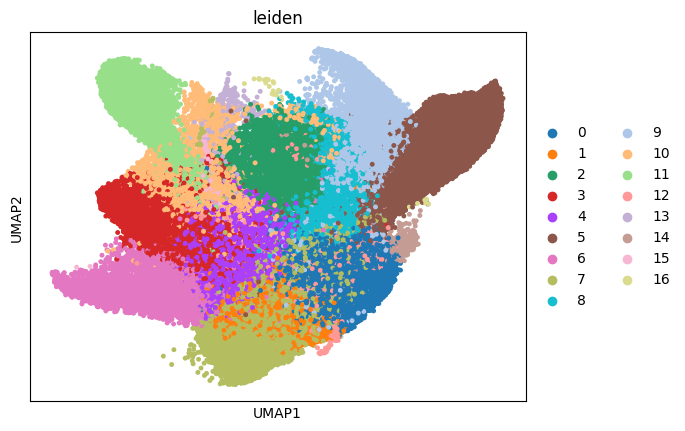

In [6]:
sc.pl.umap(adata_mgk, color="leiden", s=50)

## Check comparison CD41a 

In [7]:
cd41a_df = {"CD41a": adata_mgk[:,"CD41a"].X.toarray().ravel(), 
           "experiment_number": adata_mgk.obs["experiment_number"].values}

In [8]:
cd41a_df = pd.DataFrame(cd41a_df)

<Axes: xlabel='experiment_number', ylabel='CD41a'>

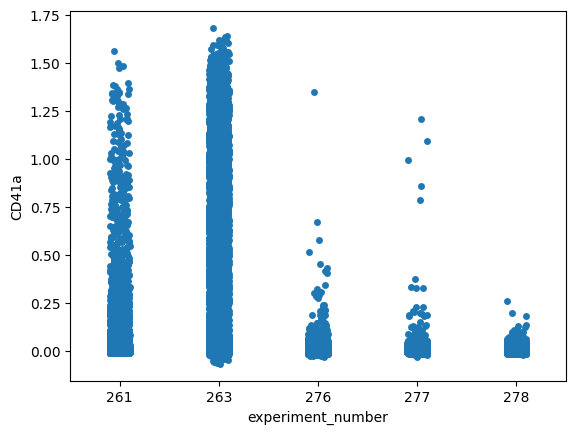

In [9]:
sns.stripplot(cd41a_df, x="experiment_number", y="CD41a")

# Classification 

In [10]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [11]:
# Standardization parameters 
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

adata_mgk.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_mgk.obs.columns
]

In [12]:
X_channel = adata_mgk.X
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = []

for col in config.annotation.scatter_columns:
    col_vals = adata_mgk.obs[col].astype(float).values
    X_scatter.append(col_vals)
    
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)

print(f"{X_channel.shape=} {X_scatter.shape=}")

X_channel.shape=(125000, 20) X_scatter.shape=(125000, 6)


In [13]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

100%|██████████| 32/32 [00:01<00:00, 26.46it/s]


In [14]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [15]:
ct_predictions_str = classes[ct_predictions]
adata_mgk.obs["cell_type"] = ct_predictions_str

/tmp/ipykernel_2643124/1121536839.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mgk.obs["cell_type"] = ct_predictions_str


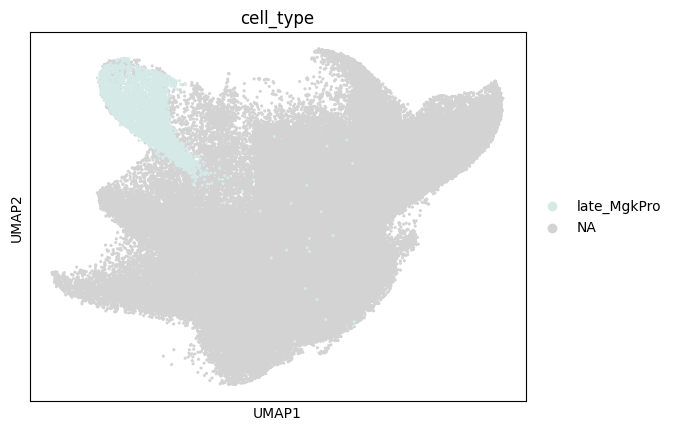

In [16]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="late_MgkPro")

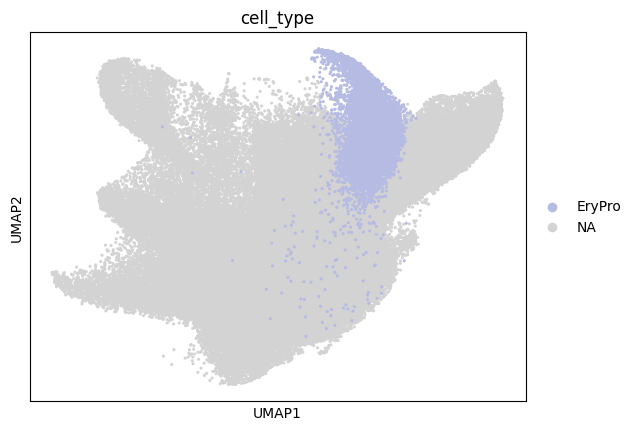

In [17]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="EryPro")

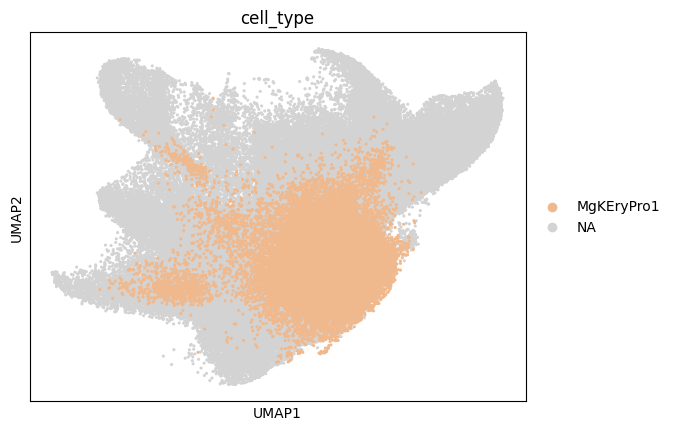

In [18]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="MgKEryPro1")

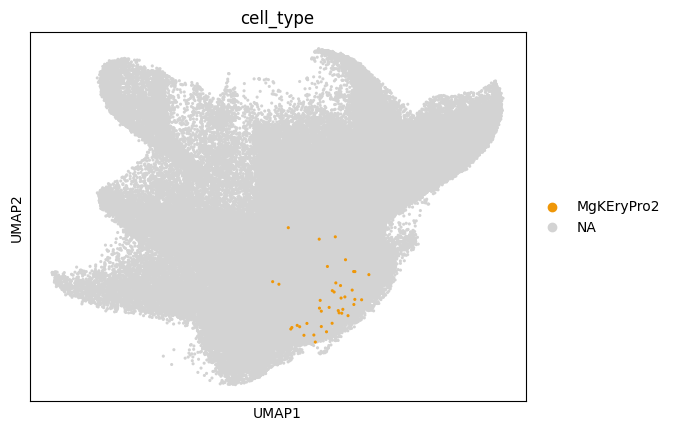

In [19]:
sc.pl.umap(adata_mgk, color="cell_type", s=20, groups="MgKEryPro2")

/tmp/ipykernel_2643124/3637018849.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


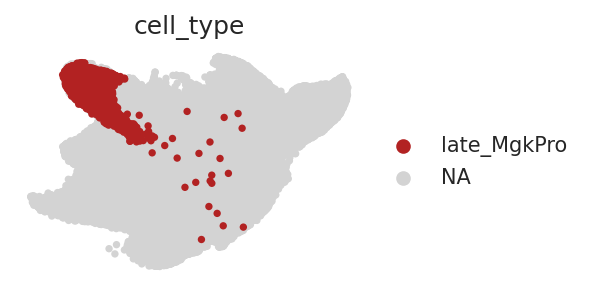

In [31]:
with plt.rc_context({"figure.figsize": (3, 2), "figure.dpi": 150}):
    sc.pl.umap(
        adata_mgk,
        color="cell_type",
        s=50,
        groups="late_MgkPro",
        palette=["firebrick"],
        frameon=False,
        save="_mgkpro_umap.png",
    )

## Plot cell type props

In [48]:
unique_ct = np.unique(adata_mgk.obs["cell_type"])

In [49]:
props_per_exp = {"Exp": [], 
                "mean_cd41a": [],
                "prop_mgk": [], 
                "prop_mgk_lin": []}
for exp in experiments:
    adata_mgk_exp = adata_mgk[adata_mgk.obs["experiment_number"]==exp]
    props = adata_mgk_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_mgk"].append(props["late_MgkPro"])    
    props_per_exp["prop_mgk_lin"].append(props["late_MgkPro"] + props["MgKEryPro1"] + props["MgKEryPro2"])
    cd41a_vals = adata_mgk_exp[:, "CD41a"].X.toarray().ravel()
    top25_thresh = np.quantile(cd41a_vals, 0.75)
    props_per_exp["mean_cd41a"].append(cd41a_vals[cd41a_vals >= top25_thresh].mean())

props_per_exp_df = pd.DataFrame(props_per_exp)
props_per_exp_df

,Exp,mean_cd41a,prop_mgk,prop_mgk_lin
0,261,0.067803,0.01608,0.29352
1,263,0.623038,0.13328,0.29344
2,276,0.015490,0.00068,0.19428
3,277,0.012440,0.00036,0.20232
4,278,0.017053,0.00000,0.04872


In [50]:
props_per_exp_df = pd.DataFrame(props_per_exp)

In [51]:
neg_control_row = (
    props_per_exp_df[props_per_exp_df.Exp.isin(["276", "277", "278"])]
    .drop(columns="Exp")
    .apply(pd.to_numeric, errors="coerce")
    .mean()
)
neg_control_row["Exp"] = "negative control"

props_per_exp_df = props_per_exp_df[~props_per_exp_df.Exp.isin(["276", "277", "278"])]

props_per_exp_df = pd.concat(
    [props_per_exp_df, neg_control_row.to_frame().T],
    ignore_index=True
)

props_per_exp_df

,Exp,mean_cd41a,prop_mgk,prop_mgk_lin
0,261,0.067803,0.01608,0.29352
1,263,0.623038,0.13328,0.29344
2,negative control,0.014995,0.000347,0.14844


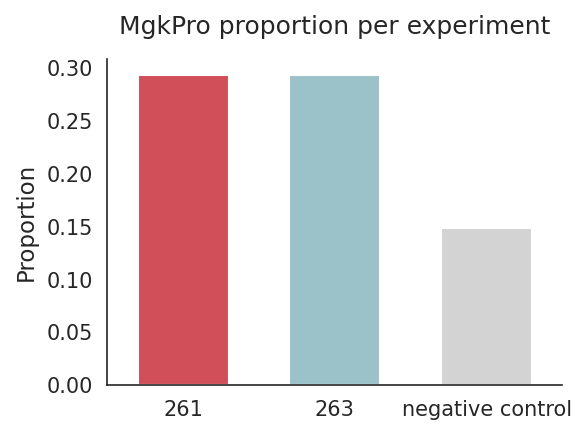

In [52]:
sns.set_style("white")

color_map = {
    "261": "#E63946",
    "263": "#94C7CF",
    "negative control": "lightgray",
}

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

sns.barplot(
    props_per_exp_df,
    x="Exp",
    y="prop_mgk_lin",
    hue="Exp",
    palette=color_map,
    legend=False,
    width=0.6,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Proportion", fontsize=11)
ax.set_title("MgkPro proportion per experiment", fontsize=12, pad=12)
sns.despine(ax=ax)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
fig.savefig("../plots/prop_mgk_lin_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparison old protocols

In [53]:
adata_l1 = sc.read_h5ad("../../../project_folder/output/loops/data/loop1/adata_500k.h5ad")
adata_l2 = sc.read_h5ad("../../../project_folder/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_l2p5 = sc.read_h5ad("../../../project_folder/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")
adata_l3 = sc.read_h5ad("../../../project_folder/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

In [54]:
adata_concat = sc.concat([adata_l1, adata_l2, adata_l2p5, adata_l3])                       

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [55]:
adata_concat.obs["experiment_number"] = adata_concat.obs["experiment_number"].astype(str)

In [56]:
for exp in np.unique(adata_concat.obs.experiment_number):
    adata_mgk_exp = adata_concat[adata_concat.obs["experiment_number"]==exp]
    props = adata_mgk_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
            
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_mgk"].append(props["late_MgkPro"])
    props_per_exp["prop_mgk_lin"].append(props["late_MgkPro"] + props["MgKEryPro1"] + props["MgKEryPro2"])
    cd41a_vals = adata_mgk_exp[:, "CD41a"].X.toarray().ravel()
    top25_thresh = np.quantile(cd41a_vals, 0.75)
    props_per_exp["mean_cd41a"].append(cd41a_vals[cd41a_vals >= top25_thresh].mean())

props_per_exp_df = pd.DataFrame(props_per_exp)
props_per_exp_df

,Exp,mean_cd41a,prop_mgk,prop_mgk_lin
0,261,0.067803,0.016080,0.293520
1,263,0.623038,0.133280,0.293440
2,276,0.015490,0.000680,0.194280
3,277,0.012440,0.000360,0.202320
4,278,0.017053,0.000000,0.048720
...,...,...,...,...
142,66,0.040109,0.006547,0.254596
143,67,0.025082,0.002091,0.051228
144,77,0.037848,0.008532,0.274780
145,78,0.029849,0.007241,0.290387


In [57]:
props_per_exp = pd.DataFrame(props_per_exp)

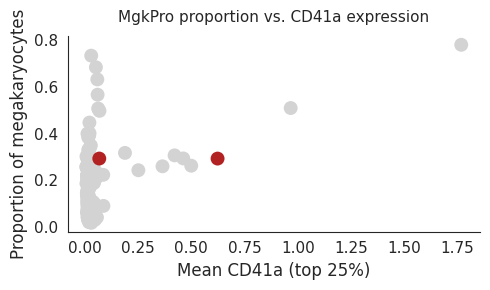

In [62]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 3))
highlight = ["261",
               "263"]

# Split into background (non-highlighted) and foreground (highlighted) subsets
bg_df = props_per_exp_df[~props_per_exp_df["Exp"].isin(highlight)]
fg_df = props_per_exp_df[props_per_exp_df["Exp"].isin(highlight)]

# Plot background points first
sns.scatterplot(
    data=bg_df,
    x="mean_cd41a",
    y="prop_mgk_lin",
    s=100,
    edgecolor="none",
    color="lightgray",
    ax=ax,
    zorder=1,
)

# Plot highlighted points last so they render on top
sns.scatterplot(
    data=fg_df,
    x="mean_cd41a",
    y="prop_mgk_lin",
    s=100,
    edgecolor="none",
    color="firebrick",
    ax=ax,
    zorder=5,
)

ax.set_xlabel("Mean CD41a (top 25%)", fontsize=12)
ax.set_ylabel("Proportion of megakaryocytes", fontsize=12)
ax.set_title("MgkPro proportion vs. CD41a expression", fontsize=11, pad=10)
ax.tick_params(axis="both", labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("../plots/mgkpro_scatter.png", dpi=300, bbox_inches="tight")
plt.show()